# Lesson: Fit S-curves to separated mock data

This notebook teaches the basic workflow for creating mock data with separated clusters, fitting an S-curve to each group, and checking whether the fitted curves make sense.

We will use a logistic S-curve because it is a common model for adoption, conversion, capacity growth, and cumulative progress.

## 1. The S-curve model

A logistic S-curve starts near a baseline, grows fastest around a midpoint, then approaches a final saturation level.

$$
y = baseline + amplitude \times \frac{1}{1 + e^{-growth\_rate(x - midpoint)}}
$$

Parameter meaning:

- `baseline`: starting level before growth
- `amplitude`: distance from the baseline to the final level
- `midpoint`: x-value where the curve grows fastest
- `growth_rate`: steepness of the curve

## 2. Imports

If these packages are missing in your notebook environment, install them once with:

```python
%pip install numpy pandas matplotlib scipy
```

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import expit

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 3)

## 3. Define the S-curve function

`expit(z)` is the stable SciPy version of `1 / (1 + exp(-z))`. It avoids overflow when `z` is very large or very small.

In [3]:
def logistic_s_curve(x, baseline, amplitude, midpoint, growth_rate):
    """Return a logistic S-curve value for each x."""
    return baseline + amplitude * expit(growth_rate * (x - midpoint))

## 4. Create separated mock data

The mock data below has three groups. Each group is observed in separated x-ranges instead of one continuous block. This simulates real datasets where observations arrive in batches or where some time periods are missing.

In [4]:
rng = np.random.default_rng(42)

true_params = {
    "Segment A": {"baseline": 5, "amplitude": 95, "midpoint": 36, "growth_rate": 0.13, "noise": 4.0},
    "Segment B": {"baseline": 8, "amplitude": 75, "midpoint": 44, "growth_rate": 0.09, "noise": 3.5},
    "Segment C": {"baseline": 2, "amplitude": 120, "midpoint": 30, "growth_rate": 0.18, "noise": 5.0},
}

separated_windows = {
    "Segment A": [(0, 12, 12), (22, 38, 16), (52, 70, 18)],
    "Segment B": [(4, 18, 12), (30, 48, 16), (58, 78, 18)],
    "Segment C": [(0, 10, 11), (18, 34, 17), (44, 64, 16)],
}

rows = []

for segment, windows in separated_windows.items():
    params = true_params[segment]

    for start, stop, n_points in windows:
        x = np.linspace(start, stop, n_points)
        y_clean = logistic_s_curve(
            x,
            params["baseline"],
            params["amplitude"],
            params["midpoint"],
            params["growth_rate"],
        )
        y_observed = y_clean + rng.normal(0, params["noise"], size=n_points)

        for x_value, y_value, y_true in zip(x, y_observed, y_clean):
            rows.append(
                {
                    "segment": segment,
                    "x": x_value,
                    "y": y_value,
                    "true_y": y_true,
                }
            )

data = pd.DataFrame(rows)
data.head(10)

,segment,x,y,true_y
0,Segment A,0.000,7.092,5.873
1,Segment A,1.091,1.845,6.005
2,Segment A,2.182,9.158,6.156
3,Segment A,3.273,10.092,6.330
4,Segment A,4.364,-1.275,6.529
5,Segment A,5.455,1.549,6.758
6,Segment A,6.545,7.532,7.020
7,Segment A,7.636,6.056,7.321
8,Segment A,8.727,7.597,7.664
9,Segment A,9.818,4.645,8.057


## 5. Plot the separated observations

Before fitting, always look at the raw data. The visible gaps along the x-axis show that the data is separated into windows.

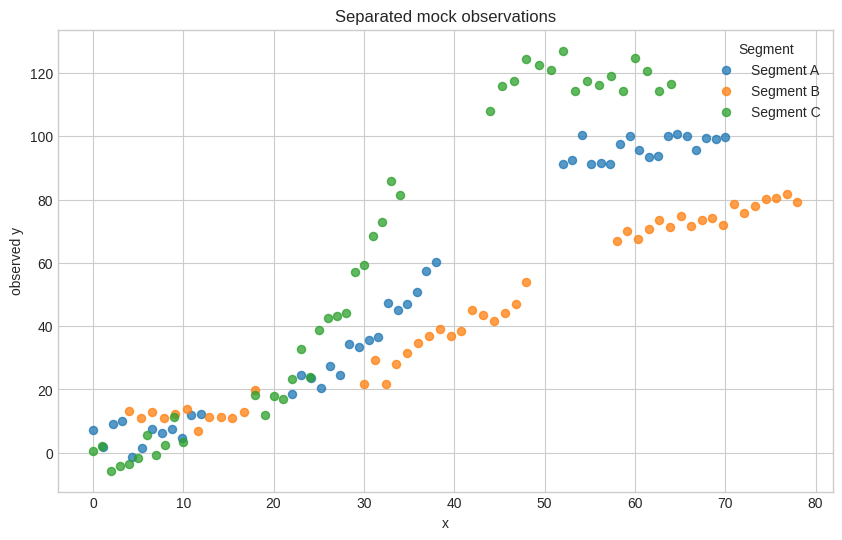

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

for segment, group in data.groupby("segment"):
    ax.scatter(group["x"], group["y"], s=34, alpha=0.75, label=segment)

ax.set_title("Separated mock observations")
ax.set_xlabel("x")
ax.set_ylabel("observed y")
ax.legend(title="Segment")
plt.show()

## 6. Fit one S-curve per segment

Nonlinear curve fitting needs a reasonable starting guess. The helper below estimates starting values from each segment:

- low percentile of `y` as the starting baseline
- high minus low percentile as the amplitude
- x-value nearest the halfway y-level as the midpoint
- a moderate positive value as the growth rate

The bounds keep the optimizer in a realistic parameter range.

In [6]:
def make_initial_guess(group):
    x = group["x"].to_numpy()
    y = group["y"].to_numpy()

    baseline = np.percentile(y, 5)
    upper = np.percentile(y, 95)
    amplitude = max(upper - baseline, 1.0)
    halfway = baseline + amplitude / 2
    midpoint = x[np.argmin(np.abs(y - halfway))]
    growth_rate = 0.1

    return [baseline, amplitude, midpoint, growth_rate]


def make_bounds(group):
    x = group["x"].to_numpy()
    y = group["y"].to_numpy()

    y_span = max(y.max() - y.min(), 1.0)
    x_span = max(x.max() - x.min(), 1.0)

    lower_bounds = [y.min() - y_span, 0.1, x.min() - x_span, 0.001]
    upper_bounds = [y.max() + y_span, 3 * y_span, x.max() + x_span, 1.0]

    return lower_bounds, upper_bounds


def fit_segment_s_curve(group):
    x = group["x"].to_numpy()
    y = group["y"].to_numpy()
    initial_guess = make_initial_guess(group)
    bounds = make_bounds(group)

    params, covariance = curve_fit(
        logistic_s_curve,
        x,
        y,
        p0=initial_guess,
        bounds=bounds,
        maxfev=20_000,
    )

    fitted_y = logistic_s_curve(x, *params)
    residuals = y - fitted_y
    rmse = np.sqrt(np.mean(residuals**2))

    return params, covariance, rmse

In [7]:
fit_rows = []
curve_rows = []
residual_rows = []

for segment, group in data.groupby("segment"):
    params, covariance, rmse = fit_segment_s_curve(group)
    baseline, amplitude, midpoint, growth_rate = params
    final_level = baseline + amplitude

    fit_rows.append(
        {
            "segment": segment,
            "baseline": baseline,
            "amplitude": amplitude,
            "final_level": final_level,
            "midpoint": midpoint,
            "growth_rate": growth_rate,
            "rmse": rmse,
        }
    )

    x_grid = np.linspace(group["x"].min(), group["x"].max(), 300)
    y_grid = logistic_s_curve(x_grid, *params)

    curve_rows.extend(
        {"segment": segment, "x": x_value, "fitted_y": y_value}
        for x_value, y_value in zip(x_grid, y_grid)
    )

    fitted_observed_x = logistic_s_curve(group["x"].to_numpy(), *params)
    residual_rows.extend(
        {
            "segment": segment,
            "x": x_value,
            "residual": y_value - fitted_value,
        }
        for x_value, y_value, fitted_value in zip(group["x"], group["y"], fitted_observed_x)
    )

fit_summary = pd.DataFrame(fit_rows)
fitted_curves = pd.DataFrame(curve_rows)
residuals = pd.DataFrame(residual_rows)

fit_summary

,segment,baseline,amplitude,final_level,midpoint,growth_rate,rmse
0,Segment A,4.476,96.036,100.512,35.781,0.13,3.080
1,Segment B,8.517,74.910,83.426,44.649,0.09,2.452
2,Segment C,-0.178,120.592,120.415,29.630,0.19,4.242


## 7. Compare the fitted curves with the data

A good fitted S-curve should pass through the center of each segment's noisy observations and should not bend wildly between separated windows.

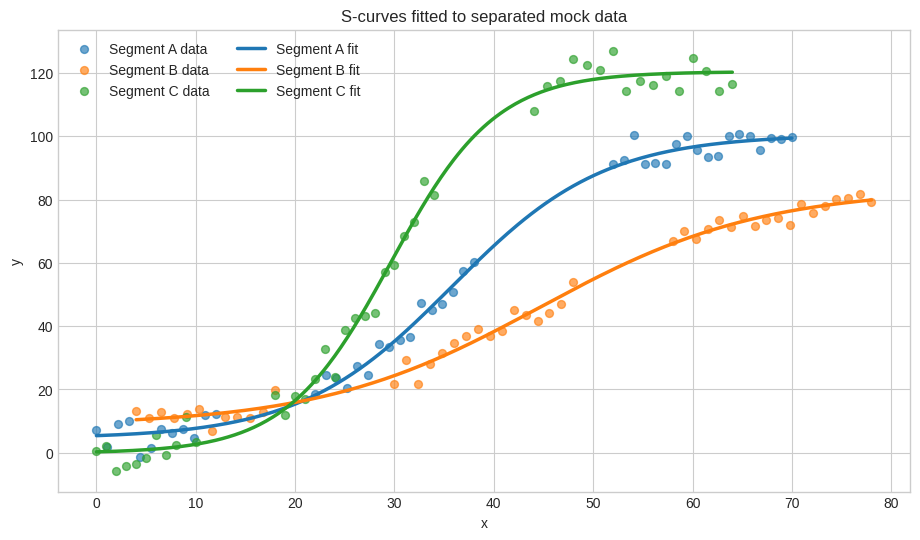

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))

for segment, group in data.groupby("segment"):
    ax.scatter(group["x"], group["y"], s=32, alpha=0.65, label=f"{segment} data")

for segment, group in fitted_curves.groupby("segment"):
    ax.plot(group["x"], group["fitted_y"], linewidth=2.5, label=f"{segment} fit")

ax.set_title("S-curves fitted to separated mock data")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(ncol=2)
plt.show()

## 8. Check residuals

Residuals are the differences between observed values and fitted values. Random scatter around zero is usually acceptable. Strong patterns can mean the S-curve is missing something important.

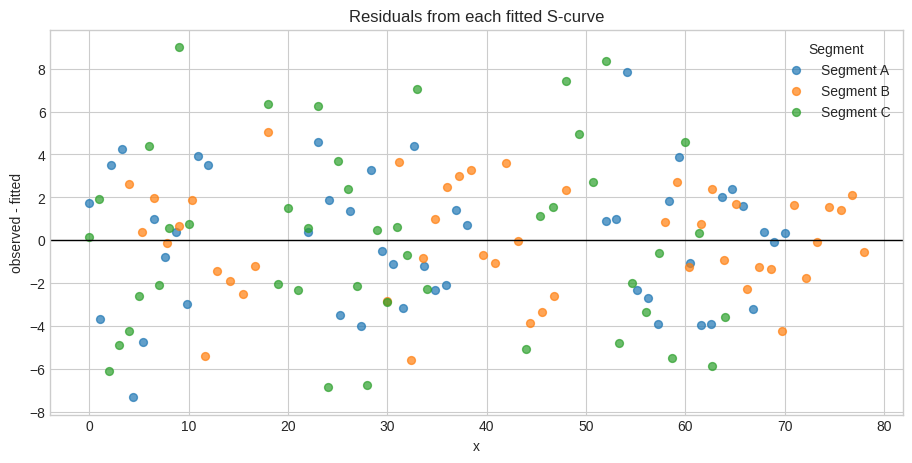

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))

for segment, group in residuals.groupby("segment"):
    ax.scatter(group["x"], group["residual"], s=32, alpha=0.7, label=segment)

ax.axhline(0, color="black", linewidth=1)
ax.set_title("Residuals from each fitted S-curve")
ax.set_xlabel("x")
ax.set_ylabel("observed - fitted")
ax.legend(title="Segment")
plt.show()

## 9. Optional: compare estimated parameters with the true mock parameters

Because this is mock data, we know the true parameters used to generate it. Real data will not have this table.

In [10]:
true_summary = (
    pd.DataFrame(true_params)
    .T
    .reset_index(names="segment")
    .rename(columns={"baseline": "true_baseline", "amplitude": "true_amplitude", "midpoint": "true_midpoint", "growth_rate": "true_growth_rate"})
)

comparison = fit_summary.merge(true_summary, on="segment")
comparison[
    [
        "segment",
        "baseline",
        "true_baseline",
        "amplitude",
        "true_amplitude",
        "midpoint",
        "true_midpoint",
        "growth_rate",
        "true_growth_rate",
        "rmse",
    ]
]

,segment,baseline,true_baseline,amplitude,true_amplitude,midpoint,true_midpoint,growth_rate,true_growth_rate,rmse
0,Segment A,4.476,5.0,96.036,95.0,35.781,36.0,0.13,0.13,3.080
1,Segment B,8.517,8.0,74.910,75.0,44.649,44.0,0.09,0.09,2.452
2,Segment C,-0.178,2.0,120.592,120.0,29.630,30.0,0.19,0.18,4.242


## 10. Optional: what happens if we ignore the separated groups?

If the segments have different growth patterns, fitting one curve to all rows mixes different stories together. This is often a useful diagnostic example.

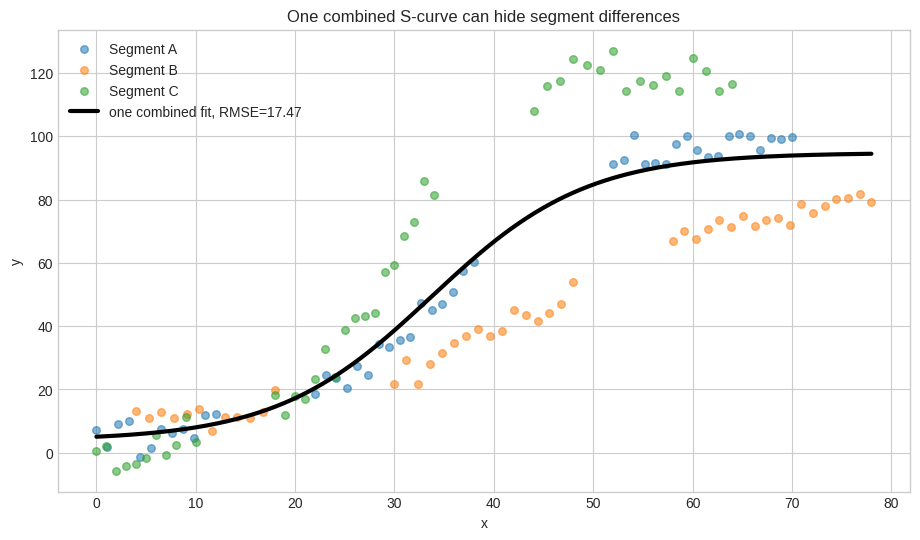

In [11]:
combined_params, _, combined_rmse = fit_segment_s_curve(data)
combined_x = np.linspace(data["x"].min(), data["x"].max(), 300)
combined_y = logistic_s_curve(combined_x, *combined_params)

fig, ax = plt.subplots(figsize=(11, 6))

for segment, group in data.groupby("segment"):
    ax.scatter(group["x"], group["y"], s=30, alpha=0.55, label=segment)

ax.plot(combined_x, combined_y, color="black", linewidth=3, label=f"one combined fit, RMSE={combined_rmse:.2f}")
ax.set_title("One combined S-curve can hide segment differences")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.show()

## 11. Early-phase diagnostic for new technology data

Yes, you can fit an S-curve in a way that asks whether the data looks like the early phase of adoption. The important limitation is that early data usually cannot estimate the full final saturation level by itself.

When the data is very early, many curves can explain the same points. A logistic S-curve, an exponential curve, and even a straight line may all look similar over a short early window. Because of that, the safer workflow is:

- use an external assumption for the possible final level, such as market size, total addressable users, or a scenario target
- fit the early data under that assumption
- check whether the fitted midpoint is still in the future
- check whether current adoption is still a small share of the assumed final level
- report this as evidence that the data is consistent with early S-curve behavior, not proof of the exact future curve

In [12]:
early_rng = np.random.default_rng(7)

early_x_windows = [np.linspace(0, 8, 9), np.linspace(14, 24, 11)]
early_x = np.concatenate(early_x_windows)

early_true_params = {
    "baseline": 1.0,
    "amplitude": 99.0,
    "midpoint": 45.0,
    "growth_rate": 0.11,
}

early_y_clean = logistic_s_curve(early_x, **early_true_params)
early_y = np.clip(early_y_clean + early_rng.normal(0, 1.4, size=len(early_x)), 0, None)

early_tech = pd.DataFrame(
    {
        "x": early_x,
        "adoption": early_y,
        "clean_adoption": early_y_clean,
    }
)

early_tech.head()

,x,adoption,clean_adoption
0,0.0,1.698,1.696
1,1.0,2.195,1.777
2,2.0,1.482,1.866
3,3.0,0.719,1.966
4,4.0,1.440,2.077


Here we pretend we have a rough scenario that the final adoption level could be around `100`. This could come from market research, product capacity, number of possible customers, or a planning scenario.

By fixing the final level, we ask a narrower and more realistic question: given this possible final level, does the current data look like it is still before the fast-growth middle of the S-curve?

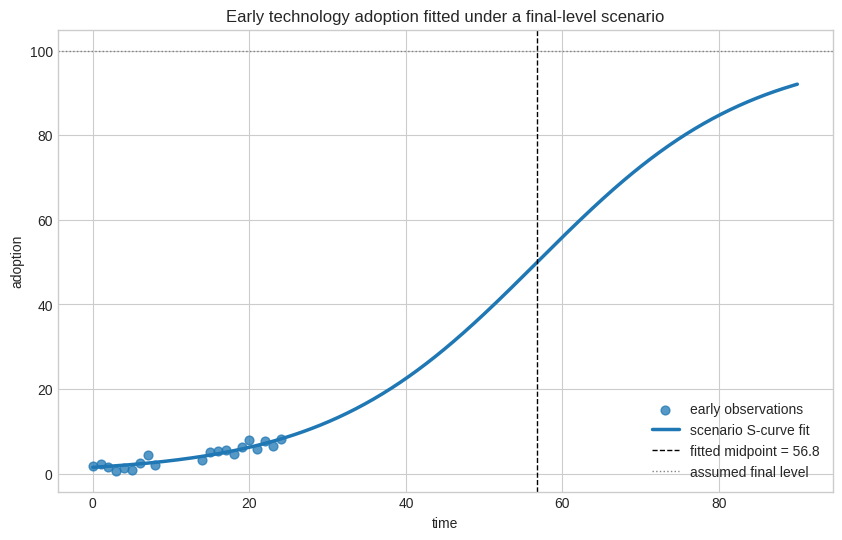

In [13]:
def logistic_with_fixed_final(x, baseline, midpoint, growth_rate, final_level):
    amplitude = final_level - baseline
    return baseline + amplitude * expit(growth_rate * (x - midpoint))


assumed_final_level = 100.0

early_params, early_covariance = curve_fit(
    lambda x, baseline, midpoint, growth_rate: logistic_with_fixed_final(
        x,
        baseline,
        midpoint,
        growth_rate,
        assumed_final_level,
    ),
    early_tech["x"],
    early_tech["adoption"],
    p0=[max(0.0, early_tech["adoption"].min()), early_tech["x"].max() + 20, 0.10],
    bounds=([
        0.0,
        early_tech["x"].max(),
        0.001,
    ], [
        assumed_final_level * 0.5,
        early_tech["x"].max() + 200,
        1.0,
    ]),
    maxfev=20_000,
)

early_baseline, early_midpoint, early_growth_rate = early_params

early_x_grid = np.linspace(early_tech["x"].min(), 90, 400)
early_y_fit = logistic_with_fixed_final(
    early_x_grid,
    early_baseline,
    early_midpoint,
    early_growth_rate,
    assumed_final_level,
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(early_tech["x"], early_tech["adoption"], s=40, alpha=0.75, label="early observations")
ax.plot(early_x_grid, early_y_fit, linewidth=2.5, label="scenario S-curve fit")
ax.axvline(early_midpoint, color="black", linestyle="--", linewidth=1, label=f"fitted midpoint = {early_midpoint:.1f}")
ax.axhline(assumed_final_level, color="gray", linestyle=":", linewidth=1, label="assumed final level")
ax.set_title("Early technology adoption fitted under a final-level scenario")
ax.set_xlabel("time")
ax.set_ylabel("adoption")
ax.legend()
plt.show()

The table below turns the fitted curve into a simple diagnostic. These checks are intentionally conservative. They should be used as evidence, not as a guarantee.

In [14]:
last_x = early_tech["x"].max()
latest_adoption = early_tech.loc[early_tech["x"].idxmax(), "adoption"]
latest_share_of_final = latest_adoption / assumed_final_level
midpoint_is_future = early_midpoint > last_x
share_is_low = latest_share_of_final < 0.30
observed_range_share = (early_tech["adoption"].max() - early_tech["adoption"].min()) / assumed_final_level

early_phase_score = sum([midpoint_is_future, share_is_low, observed_range_share < 0.35])

diagnostic = pd.DataFrame(
    [
        {
            "assumed_final_level": assumed_final_level,
            "latest_x": last_x,
            "latest_adoption": latest_adoption,
            "latest_share_of_final": latest_share_of_final,
            "fitted_midpoint": early_midpoint,
            "midpoint_after_latest_data": midpoint_is_future,
            "observed_range_share_of_final": observed_range_share,
            "early_phase_score_0_to_3": early_phase_score,
            "interpretation": "likely early phase" if early_phase_score >= 2 else "not clearly early phase",
        }
    ]
)

diagnostic

,assumed_final_level,latest_x,latest_adoption,latest_share_of_final,fitted_midpoint,midpoint_after_latest_data,observed_range_share_of_final,early_phase_score_0_to_3,interpretation
0,100.0,24.0,8.134,0.081,56.78,True,0.074,3,likely early phase


Practical interpretation:

- If the fitted midpoint is after the latest observation, the data is before the fastest-growth part of the assumed S-curve.
- If the latest value is still a small share of the assumed final level, adoption may still be early.
- If the observed data covers only a small vertical range, the future plateau is weakly identified.
- If changing the assumed final level changes the answer a lot, the data is too early to make a strong claim.

For real new technology data, the most honest result is often a scenario table: one fit for a conservative final level, one for a base case, and one for an optimistic final level.

## Key takeaways

- Keep separated observations in a tidy table with one row per observation.
- Fit one curve per group when groups have different growth behavior.
- Give nonlinear fitting a reasonable starting guess and realistic bounds.
- Plot the raw points, fitted curves, and residuals before trusting the parameters.
- For very early new technology data, fit scenario curves with assumed final levels instead of pretending the final plateau is known from the early points alone.
- Be careful when the data does not cover the lower flat part, the fast-growth middle, or the upper flat part. Missing parts make S-curve parameters less certain.

Exercises:

1. Increase the `noise` values and rerun the notebook.
2. Move one segment's `midpoint` outside the observed x-range and inspect the fit.
3. Add a fourth segment with its own separated windows.
4. Remove the final observation window from one segment and see how the final level changes.
5. In the early-phase section, change `assumed_final_level` to `60`, `100`, and `160` and compare the diagnostic table.